# Amazon Reviews Analysis — Part 1: Data Exploration & Feature Engineering

This notebook explores customer reviews and product metadata from the
[Amazon Reviews 2023](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) dataset
(McAuley Lab) for five product categories: **Automotive, Baby Products, Musical Instruments,
Home & Kitchen, Sports & Outdoors**.

**Tasks**

1. **Data exploration** — rating distributions, keywords/phrases in low-rated products,
   features of best-selling products, and rating trends over time.
2. **Sentiment features** — a combined score from VADER sentiment and the star rating.
3. **Rating normalisation** — a review-count-weighted product rating.

**How to run.** The notebook was developed on Google Colab. The data-preparation cells
(streaming from Hugging Face + spaCy cleaning) are slow, so they are run once and their CSV output is cached
on Google Drive; the remaining cells reload those CSVs.

##Setup

In [ ]:
!pip install datasets matplotlib seaborn --upgrade
import os
import itertools
from itertools import islice
import re
import ast
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate
import numpy as np

from datasets import load_dataset   # load_dataset function from Hugging Face.

import seaborn as sns               # Used for ploting.

In [ ]:
import spacy                       # Used for preprocessing.
nlp = spacy.load("en_core_web_sm")

from nltk.sentiment.vader import SentimentIntensityAnalyzer  # Used for sentiment analysis.
import nltk
nltk.download('vader_lexicon')

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer  # Used for bigrams.
from sklearn.preprocessing import MinMaxScaler

#Part 1 - Pre-processing


##Task 1: Data Exploration and Feature Engineering


###Dataset Preparation

The configuration below maps each category to its review and metadata split on Hugging Face,
and lists the fields a record must contain to be kept.

In [ ]:
categories_D = {          # Dictionary of categories and their corresponding dataset names.
    "Automotive": "raw_review_Automotive",
    "Baby_Products": "raw_review_Baby_Products",
    "Musical_Instruments": "raw_review_Musical_Instruments",
    "Home_and_Kitchen": "raw_review_Home_and_Kitchen",
    "Sports_and_Outdoors": "raw_review_Sports_and_Outdoors"
}

categories_metadata_D = {
    "Automotive_meta": "raw_meta_Automotive",
    "Baby_Products_meta": "raw_meta_Baby_Products",
    "Musical_Instruments_meta": "raw_meta_Musical_Instruments",
    "Home_and_Kitchen_meta": "raw_meta_Home_and_Kitchen",
    "Sports_and_Outdoors_meta": "raw_meta_Sports_and_Outdoors"
}

requiredFields = ["rating", "title", "text", "asin", "timestamp"]   # Required fields for the dataset (reviews).
requiredFields_metadata = ['price', 'average_rating', 'description']


#### Helper functions for data parsingng

In [ ]:
# Check if price and rating values are valid.

def is_valid_price(val):
    try:
        return val is not None and val != '' and float(val) >= 0
    except:
        return False

def is_valid_rating(val):
    try:
        return val is not None and val != '' and 0 <= float(val) <= 5
    except:
        return False

In [ ]:
# Select a specified number of rows from the dataset (reviews).
def select_entries_reviews(dataset, rows=1000):

    selected = []

    for entry in dataset:
        if all(field in entry and entry[field] for field in requiredFields):  # If important fields are missing, dont select the row.
            selected.append(entry)
        if len(selected) == rows:     # If the number of selected rows reaches the limit, break the loop.
            break

    return pd.DataFrame(selected)     # Convert the selected entries to a DataFrame.


# Select a specified number of rows from the dataset (metadata).
def select_entries_metadata(dataset, rows=1000):
    selected = []
    count = 0

    for entry in dataset:
        if all(field in entry and entry[field] for field in requiredFields_metadata):
            if is_valid_price(entry['price']) and is_valid_rating(entry['average_rating']):
                selected.append(entry)     # Only select rows with valid price and rating values.
                count += 1
                if count >= rows * 1.2:  # Collect extra in case some get removed after cleaning.
                    break

    df = pd.DataFrame(selected)
    df['description'] = df['description'].apply(flatten_discription)      # Flatten and clean the description field.
    df['description_cleaned'] = df['description'].apply(clean_text)
    df = df[df['description_cleaned'].notna() & (df['description_cleaned'] != "")]

    print(len(df))

    return df.head(rows)


# Clean the text by removing unwanted characters, lemmatizing and normalizing whitespace.
def clean_text(text):

    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    doc = nlp(text)                        # Process the text with spaCy.

    words = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha] # Remove stopwords, and lemmatize

    return " ".join(words)


# Create the csv file for the dataset.
def create_csv(df, category, rows):

    category = category.replace(" ", "_")  # Replace spaces with underscores in the category name.
    filename = f"{category}.csv"  # Create a filename for the CSV file.

    df.to_csv(filename, index=False)  # Save the DataFrame to a CSV file.

    print(f"Created {filename} with {rows} rows.")  # Print a message indicating the file creation.


# Convert discription list to a string.
def flatten_discription(x):
    if isinstance(x, str) and x.startswith('[') and x.endswith(']'):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return " ".join(str(i) for i in parsed)
        except Exception:

            return x      # Parsing failed, return original string.
    return str(x)

In [ ]:
# Load reviews dataset - 50.000 rows.
for category, datasetName in categories_D.items():

    dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", datasetName, split='full', streaming=True, trust_remote_code=True)


    df = select_entries(dataset, 50000) # Select the specified number of rows from the dataset.

    df["text"] = df["text"].apply(clean_text)  # Clean the text data using the clean_text function.
    df["title"] = df["title"].apply(clean_text)  # Clean the title data using the clean_text function.

    create_csv(df, category, 50000)  # Create a CSV file for the dataset.


Created Automotive.csv with 50000 rows.
Created Baby_Products.csv with 50000 rows.
Created Musical_Instruments.csv with 50000 rows.
Created Home_and_Kitchen.csv with 50000 rows.
Created Sports_and_Outdoors.csv with 50000 rows.


In [ ]:
# Load products dataset - 500.000 rows (for part 1).
for category, datasetName in categories_metadata_D.items():

    dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", datasetName, split='full', streaming=True, trust_remote_code=True)

    features = dataset.features.copy()
    features.pop('image_url', None)               # Remove 'image_url' from the features (issue causing).
    dataset = dataset.map(lambda x: x, features=features, remove_columns=['image_url'])

    df = select_entries_metadata(dataset, 500000)  # Select the specified number of rows from the dataset.

    create_csv(df, category, 500000)     # Create a CSV file for the dataset.

In [ ]:
# Get the csv from drive (Don't have to parse every time).

from google.colab import drive
drive.mount('/content/drive')

csv_folder = "/content/drive/MyDrive/tede_csv's/"



Mounted at /content/drive


In [ ]:
# Read the csv's once and save them in dictionaries.

reviews_data = {}
meta_data = {}

for category in categories_D:
    reviews_data[category] = pd.read_csv(csv_folder + f"{category}.csv")
    meta_data[category] = pd.read_csv(csv_folder + f"{category}_meta2.csv")

###Ratings and Reviews

####Distribution of product ratings - Average rating per category

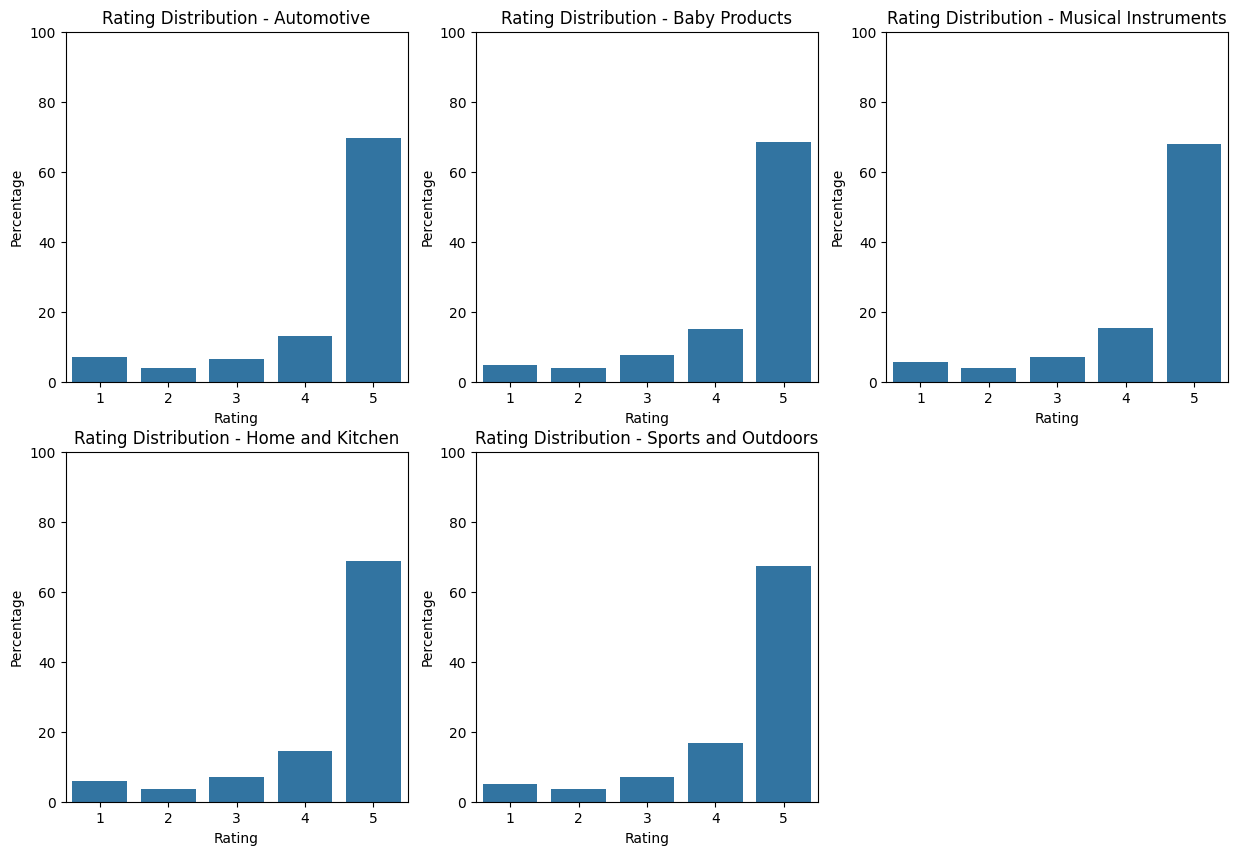

Average Ratings:
Automotive: 4.34
Baby Products: 4.38
Musical Instruments: 4.36
Home and Kitchen: 4.37
Sports and Outdoors: 4.38


In [ ]:
avgRatings_D = {}                    # Dictionary to store average ratings for each category.

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()                # Flatten axes array for indexing.

for i, category in enumerate(categories_D):

    df = reviews_data[category]

    avgRatings_D[category] = df["rating"].mean()    # Calculate the average rating for the category.

    rating_percentages = df["rating"].value_counts(normalize=True).sort_index() * 100  # Compute the percentage distribution of the ratings.


    # Plot ratings distribution.
    sns.barplot(x=range(1, 6), y=rating_percentages.values, ax=axes[i])

    axes[i].set_title(f"Rating Distribution - {category.replace('_', ' ')}")
    axes[i].set_xlabel("Rating")
    axes[i].set_ylabel("Percentage")
    axes[i].set_ylim(0, 100)          # Set y-axis limit to 100%.


for j in range(i + 1, len(axes)):     # Hide any unused subplots.
    fig.delaxes(axes[j])

plt.show()


print("Average Ratings:")      # Print average rating for each category.
for category, avg_rating in avgRatings_D.items():
    print(f"{category.replace('_', ' ')}: {avg_rating:.2f}")


The average ratings of all five categories (Automotive, Baby Products, Home and Kitchen,
Musical Instruments, Sports and Outdoors) are very close to each other, at roughly 4.36.

####Common keywords and phrases in products with low ratings.

In [ ]:
for category in categories_D:

    df = reviews_data[category]

    product = df.groupby("asin")["rating"].count()       # Calculate the number of reviews per product.
    avg_ratings = df.groupby("asin")["rating"].mean()    # Calculate the average rating per product.
    #print(avg_ratings)

    products = pd.DataFrame({
        "review_count": product,
        "avg_rating": avg_ratings
    })

    filtered_products = products[(products["review_count"] >= 6) & (products["avg_rating"] <= 3)]  # Select only products with 6+ reviews and average ratings <= 3.5.
    products_with_lowest_rating = filtered_products.sort_values("avg_rating")                        # Sort products based on the lowest average rating.


    print(f"\n\n--- Category: {category} - Products with Low Ratings and High Review Counts ---")
    print(tabulate(products_with_lowest_rating.reset_index(), headers='keys', tablefmt='pretty', showindex=False))

    bad_reviews = df[df["asin"].isin(products_with_lowest_rating.index)]     # Get all reviews for low-rated products.

    titles_and_text = bad_reviews["title"].fillna('') + " " + bad_reviews["text"].fillna('')       # Combine the title and review text.

    tokens = titles_and_text.str.split(expand=True).stack().value_counts().head(10)  # Tokenize and find the 10 most frequent words.
    print("\n--- Most Frequent Words in Reviews ---")
    print(tokens.to_string())


    # Find common phrases in these product's reviews.

    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
    X = vectorizer.fit_transform(titles_and_text)


    featureNames = vectorizer.get_feature_names_out()   # Get all bigrams.
    count = X.sum(axis=0).A1                            # Column-wise(bigram apearences) sum.

    bigrams = list(zip(featureNames, count))
    bigrams.sort(key=lambda x: x[1], reverse=True)    # Sort based on the count.

    print("\n--- Most Frequent Bigrams ---")
    for bigram, count in bigrams[:10]:
        print(f"{bigram}: {count}")






--- Category: Automotive - Products with Low Ratings and High Review Counts ---
+------------+--------------+--------------------+
|    asin    | review_count |     avg_rating     |
+------------+--------------+--------------------+
| B00AN5L8DK |      8       |        1.75        |
| B000EA5WLS |      7       | 2.4285714285714284 |
| B07TTL7ZJF |      6       |        2.5         |
| B01BUMHHWA |      7       | 2.5714285714285716 |
| B001QCWQUS |      6       |        3.0         |
| B0017K69MA |      6       |        3.0         |
| B005N53AM2 |      6       |        3.0         |
| B0002UNON8 |      9       |        3.0         |
| B01J6E2IC8 |      6       |        3.0         |
| B08BLRGWGY |      7       |        3.0         |
+------------+--------------+--------------------+

--- Most Frequent Words in Reviews ---
work       25
scratch    25
product    21
like       18
good       17
car        12
use        12
well       10
star        9
smell       9

--- Most Frequent Bigra

####Key attributes in top selling products

In [ ]:
for category in categories_D:
    df = meta_data[category]

    # Sort the DataFrame by the number of ratings and select the top 5 products.
    top5_best_sellers = df.sort_values(by="rating_number", ascending=False).head(5)

    print(f"\nTop 5 best sellers in {category}:")
    for index, row in top5_best_sellers.iterrows():  # Iterate over the rows of the DataFrame.

        features = row["features"]                   # Get the features of the product.
        features = features.strip("[]").replace("', '", "\n").replace("'", "")

        print(f"Product: {row['title']}, Ratings: {row['rating_number']}")
        print(f"Features: {features}\n")



Top 5 best sellers in Automotive:
Product: ThisWorx Car Vacuum Cleaner - Car Accessories - Small 12V High Power Handheld Portable Car Vacuum w/Attachments, 16 Ft Cord & Bag - Detailing Kit Essentials for Travel, RV Camper, Ratings: 257159
Features: PRACTICAL: A mini vacuum for car or truck that is compact, lightweight (2.4 lbs), and easy to use. Equipped with a HEPA filter, this small dustbuster is ready for ash, dust, or drive-thru food spills. A fully loaded interior car detailing kit housed in an ergonomic design
POWERFUL: This hand held vacuum is made for on-the-go use and solving out-of-reach problems. A very sandy day at the beach? A coat of dog hair? The portable vacuum cleaner for car is designed to solve problems
STRONG SUCTION: The cyclonic force and strong suction of the 106w motor on these handheld vacuums will terminate any dirt, debris, or hard-to-reach crumbs. Our mini car vacuum even has a top of the line washable filter
CAR CLEANING KIT: Includes 3 attachments for det

####Average product ratings per category over years

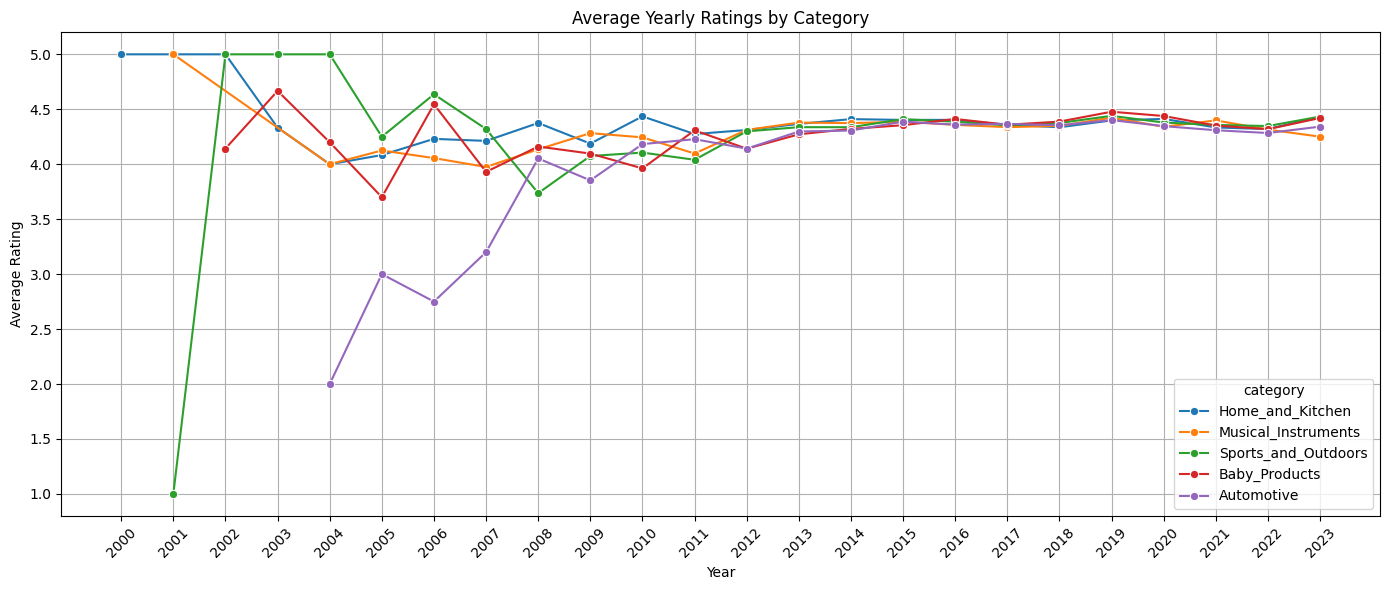

In [ ]:
all_data = [] # List to store average rating for each year for each category.

for category in categories_D:
    df = reviews_data[category]

    df['review_date'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')   # Convert timestamp to datetime format.
    df['year'] = df['review_date'].dt.to_period('Y')    # Keep only the year

    yearly_avg = df.groupby('year')['rating'].mean().reset_index()    # Calculate the average rating for each year.
    yearly_avg['year'] = yearly_avg['year'].astype(str)     # Convert it to string for plotting.
    yearly_avg['category'] = category                       # Add the category name.

    all_data.append(yearly_avg)

all_data_df = pd.concat(all_data, ignore_index=True)  # Make list with data to a dataframe.
all_data_df = all_data_df.sort_values(by='year')


plt.figure(figsize=(14, 6))
sns.lineplot(data=all_data_df, x='year', hue='category', y='rating', marker='o')

plt.title("Average Yearly Ratings by Category")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


The chart shows how the average product rating varies per category on a yearly basis. In the early years
(especially before 2011) the ratings of all categories fluctuate considerably. This is possibly due to the small
number of reviews, since online reviews were not yet widespread at the time. In addition, the first users to leave
reviews are often either particularly enthusiastic or very strict (early-adopter bias), which affects the average.
It is also possible that some products had quality problems or manufacturing defects when first released, which
could explain the low ratings. From 2013 onwards all categories stabilise, with average ratings between 4.2 and 4.4.
This suggests that users rate more consistently and that products may have improved in quality or adapted better
to consumer needs, possibly thanks to the feedback they receive.

## Task 2: Feature Engineering with Sentiment Scores and Ratings

Each review gets a combined sentiment score:

`final_sentiment_score = 0.35 * VADER compound score + 0.65 * normalised rating`

* VADER's compound score lies in [-1, 1]; the star rating is min-max normalised from [1, 5] to [0, 1].
* The rating gets the larger weight because it is an explicit signal from the reviewer.
* Note: VADER is applied to the already-cleaned text (stop words such as "not" are removed),
  so negation is not captured by the text score.

In [ ]:
vader = SentimentIntensityAnalyzer()    # Initialize the sentiment analyzer.

def get_vader_sentiment(text):    # Return the compound sentiment score from VADER's polarity_scores method.
  return vader.polarity_scores(text)['compound']  # (-1, 1)

def normalize_rating(rating):    # Return the normalized rating.
    return (rating - 1) / 4

def final_sentiment_score(vader_score, norm_rating, w1 = 0.35 , w2 = 0.65):  # Return the combined sentiment score.
    return (w1 * vader_score + w2 * norm_rating)

for category in categories_D:

    df = reviews_data[category]
    df['clean_text'] = df['text'].fillna('').str.strip()

    df['sentiment_score'] = df['clean_text'].apply(get_vader_sentiment)       # Calculate the sentiment score for each review.
    df['norm_rating'] = df['rating'].apply(normalize_rating)                  # Normalize.
    df['final_sentiment_score'] = df.apply(lambda row: final_sentiment_score  # Calculate the final sentiment score.
      (row['sentiment_score'], row['norm_rating']), axis=1)

    print(df[["text", "rating", "sentiment_score", "norm_rating", "final_sentiment_score"]].head(5))

    print("\nStats for vader sentiment:\n")
    print(df[["sentiment_score", "norm_rating", "final_sentiment_score"]].describe())

                                                text  rating  sentiment_score  \
0      item come describe fit Chevy Colorado perfect     5.0           0.7351   
1  ease application process clean area rub alcoho...     5.0           0.9260   
2  nice quality frame silver wall decoration work...     5.0           0.8625   
3  description say waterproof waterproof Waste money     2.0          -0.4215   
4                                     look great son     5.0           0.6249   

   norm_rating  final_sentiment_score  
0         1.00               0.907285  
1         1.00               0.974100  
2         1.00               0.951875  
3         0.25               0.014975  
4         1.00               0.868715  

Stats for vader sentiment:

       sentiment_score   norm_rating  final_sentiment_score
count     50000.000000  50000.000000           50000.000000
mean          0.490698      0.835015               0.714504
std           0.411270      0.300417               0.279294
min 

##Task 3: Feature Engineering with Price Metrics

### Normalised (review-count-weighted) ratings

A raw average rating is unreliable for products with few reviews. Each product's average rating is therefore
scaled by `log(1 + review_count)`, which rewards products that are both highly rated *and* widely reviewed,
while damping the effect of very large review counts.

In [ ]:
weighted_ratings = {}

for category in categories_D:
    df = reviews_data[category]

    grouped = df.groupby("asin").agg(
        review_count=("rating", "count"),
        average_rating=("rating", "mean")
    ).reset_index()

    grouped["weighted_rating"] = grouped["average_rating"] * np.log1p(grouped["review_count"])

    weighted_ratings[category] = grouped.sort_values("weighted_rating", ascending=False)